#### Import Libraries
- The libraries below are used for data analysis, visualization, preprocessing, machine learning, evaluation, 
- and saving the final model.

In [2]:
# =========================
# DATA MANIPULATION
# =========================
import pandas as pd
import numpy as np

# =========================
# DATA VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# MACHINE LEARNING PREPROCESSING
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

# =========================
# MACHINE LEARNING MODELS
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# =========================
# MODEL EVALUATION
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# =========================
# MODEL SAVING
# =========================
import joblib
import warnings

# Ignore unnecessary warning messages to keep the notebook clean
warnings.filterwarnings("ignore")

# Set visual style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Use one random state everywhere to make results reproducible
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


#### Load the Dataset

In [3]:
# Load the hotel booking dataset
# Keeping the file name simple makes the notebook easier to run on GitHub or locally.

from pathlib import Path

local_path = Path("booking.csv")
downloads_path = Path.home() / "Downloads" / "booking.csv"

if local_path.exists():
    data = pd.read_csv(local_path)
elif downloads_path.exists():
    data = pd.read_csv(downloads_path)
else:
    raise FileNotFoundError("booking.csv was not found. Please place booking.csv in the notebook folder.")

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)
data.head()

Dataset loaded successfully!
Dataset shape: (36285, 17)


,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


####  Data Understanding

In [4]:
# Display the first five rows to understand the structure of the dataset
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [5]:
# Display the last five rows to confirm the dataset loaded correctly
data.tail()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
36280,INN36282,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,9/13/2018,Canceled
36281,INN36283,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,10/15/2017,Not_Canceled
36282,INN36284,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,12/26/2018,Not_Canceled
36283,INN36285,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,7/6/2018,Not_Canceled
36284,INN36286,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,10/18/2018,Not_Canceled


In [6]:
# Check the number of rows and columns
data.shape

(36285, 17)

In [7]:
# Check column names
data.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status'],
      dtype='object')

In [8]:
# Check data types and missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [9]:
# Numerical summary helps understand ranges, averages, and possible outliers
data.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [10]:
# Categorical summary helps understand unique categories and frequent values
data.describe(include="object")

,Booking_ID,type of meal,room type,market segment type,date of reservation,booking status
count,36285,36285,36285,36285,36285,36285
unique,36285,4,7,5,553,2
top,INN00001,Meal Plan 1,Room_Type 1,Online,10/13/2018,Not_Canceled
freq,1,27842,28138,23221,254,24396


In [11]:
# Inspect unique values in categorical columns
# This helps identify inconsistent labels before preprocessing.

for col in data.select_dtypes(include="object").columns:
    print(col)
    print(data[col].unique())
    print("-" * 50)

Booking_ID
['INN00001' 'INN00002' 'INN00003' ... 'INN36284' 'INN36285' 'INN36286']
--------------------------------------------------
type of meal
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
--------------------------------------------------
room type
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']
--------------------------------------------------
market segment type
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']
--------------------------------------------------
date of reservation
['10/2/2015' '11/6/2018' '2/28/2018' '5/20/2017' '4/11/2018' '9/13/2016'
 '10/15/2017' '12/26/2018' '7/6/2018' '10/18/2018' '9/11/2018' '4/30/2018'
 '11/26/2018' '11/20/2018' '10/20/2017' '6/15/2018' '10/5/2017'
 '8/10/2017' '10/30/2017' '10/4/2017' '11/25/2018' '3/20/2018'
 '10/13/2018' '5/22/2018' '4/28/2018' '9/21/2017' '5/19/2018' '11/6/2017'
 '9/17/2017' '9/19/2017' '11/13/2018' '12/7/2018' '1/9/2018' '10/7/2018'
 '4/27/2

#### Missing Values and Date Cleaning

In [12]:
# Check missing values in each column
data.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [13]:
# Convert reservation date to datetime format
# errors='coerce' converts invalid dates into NaT so they can be handled safely.

data["date of reservation"] = pd.to_datetime(
    data["date of reservation"],
    errors="coerce"
)

# Check how many invalid dates were found
print("Invalid reservation dates:", data["date of reservation"].isna().sum())

Invalid reservation dates: 37


In [14]:
# Drop rows with invalid reservation dates
# These rows cannot be used for date-based feature engineering.

data = data.dropna(subset=["date of reservation"]).copy()

print("Shape after removing invalid dates:", data.shape)
data.isnull().sum()

Shape after removing invalid dates: (36248, 17)


Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

#### Exploratory Data Analysis

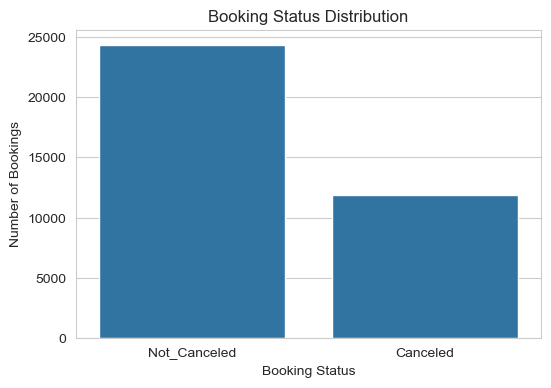

booking status
Not_Canceled    67.22026
Canceled        32.77974
Name: proportion, dtype: float64

In [15]:
# Check booking status distribution before creating the target variable
# This shows whether cancellations and non-cancellations are balanced.

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="booking status")
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

data["booking status"].value_counts(normalize=True) * 100

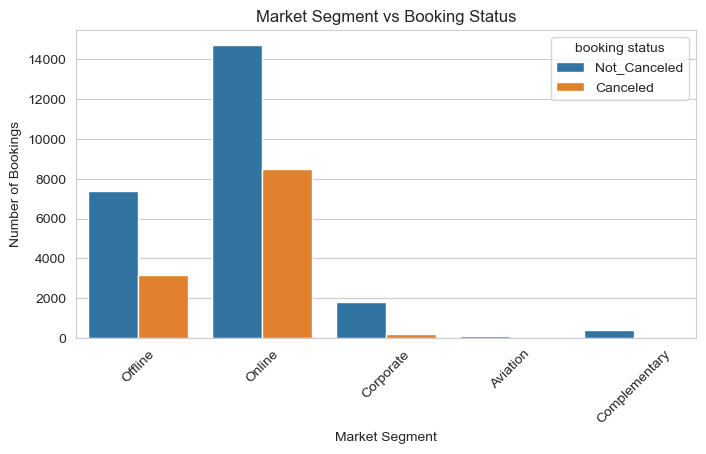

In [16]:
# Market segment vs booking status
# This helps show which sales channels have more cancellations.

plt.figure(figsize=(8, 4))
sns.countplot(
    data=data,
    x="market segment type",
    hue="booking status"
)
plt.title("Market Segment vs Booking Status")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

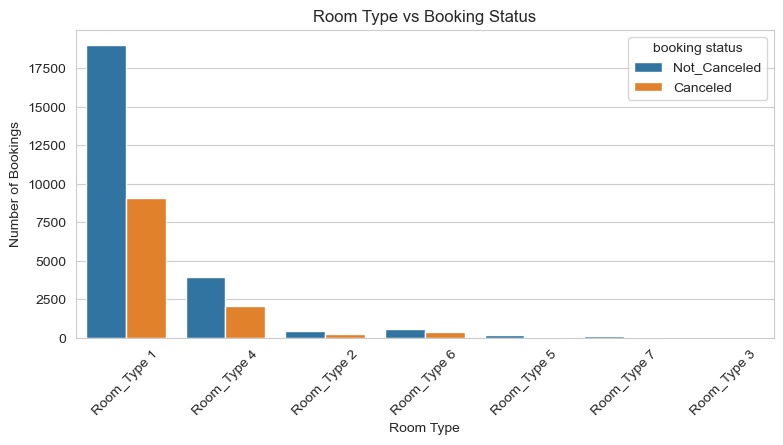

In [17]:
# Room type vs booking status
# This helps identify whether some room types are more likely to cancel.

plt.figure(figsize=(9, 4))
sns.countplot(
    data=data,
    x="room type",
    hue="booking status"
)
plt.title("Room Type vs Booking Status")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

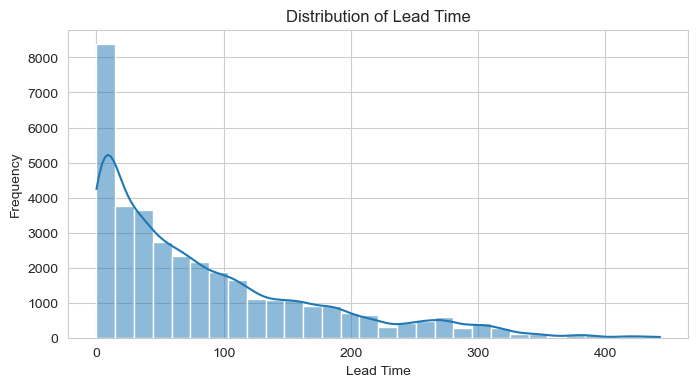

In [18]:
# Lead time distribution
# Long lead times often increase cancellation risk.

plt.figure(figsize=(8, 4))
sns.histplot(data["lead time"], bins=30, kde=True)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")
plt.show()

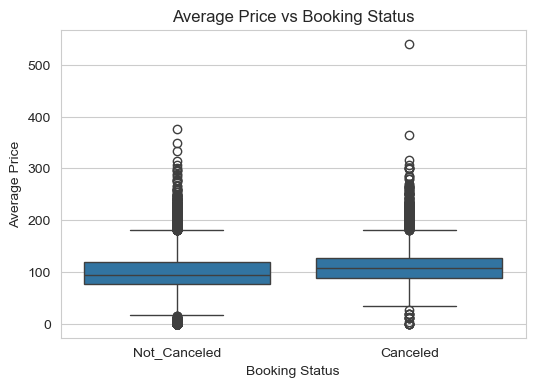

In [19]:
# Average price vs booking status
# This checks whether higher room prices are related to cancellations.

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=data,
    x="booking status",
    y="average price"
)
plt.title("Average Price vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Price")
plt.show()

####  Feature Engineering

In [20]:
# Create new features from existing columns.
# These features help the model understand booking behavior more clearly.

data["total_guests"] = data["number of adults"] + data["number of children"]
data["total_nights"] = data["number of weekend nights"] + data["number of week nights"]
data["booking_month"] = data["date of reservation"].dt.month
data["booking_day"] = data["date of reservation"].dt.day
data["booking_year"] = data["date of reservation"].dt.year

data[[
    "total_guests",
    "total_nights",
    "booking_month",
    "booking_day",
    "booking_year"
]].head()

,total_guests,total_nights,booking_month,booking_day,booking_year
0,2,7,10,2,2015
1,1,4,11,6,2018
2,3,4,2,28,2018
3,1,2,5,20,2017
4,1,3,4,11,2018


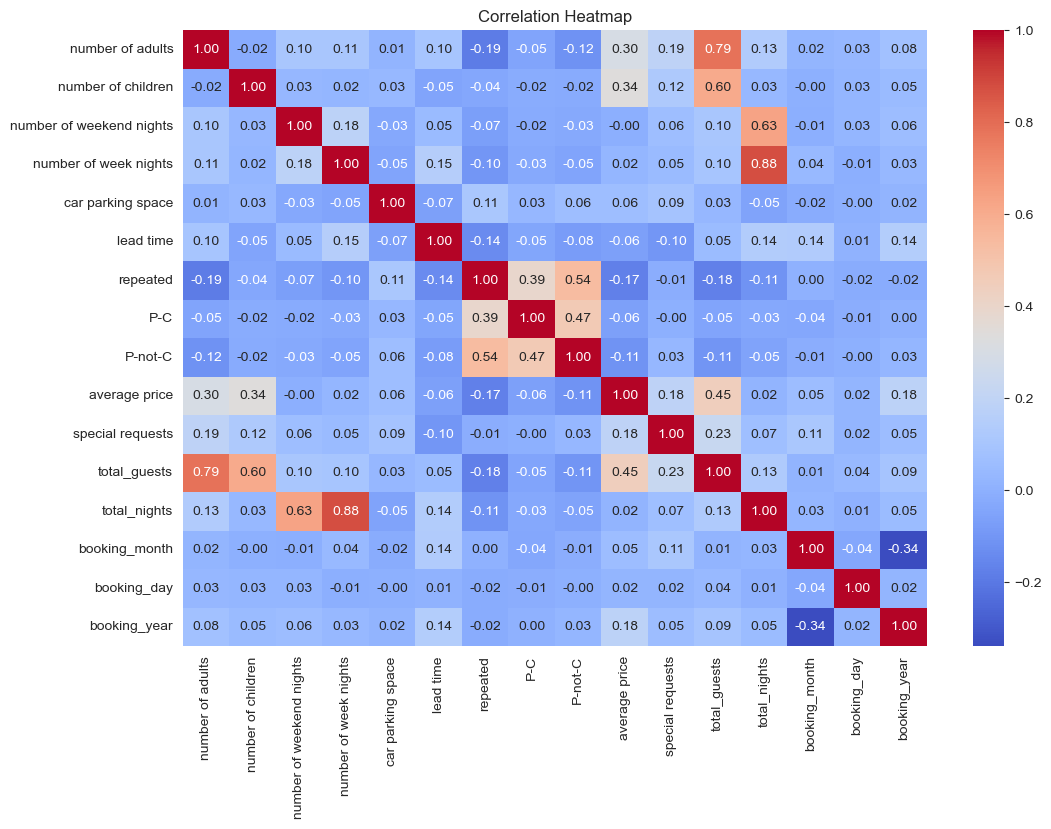

In [21]:
# Correlation heatmap for numerical variables
# This helps review relationships between numerical features.

plt.figure(figsize=(12, 8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

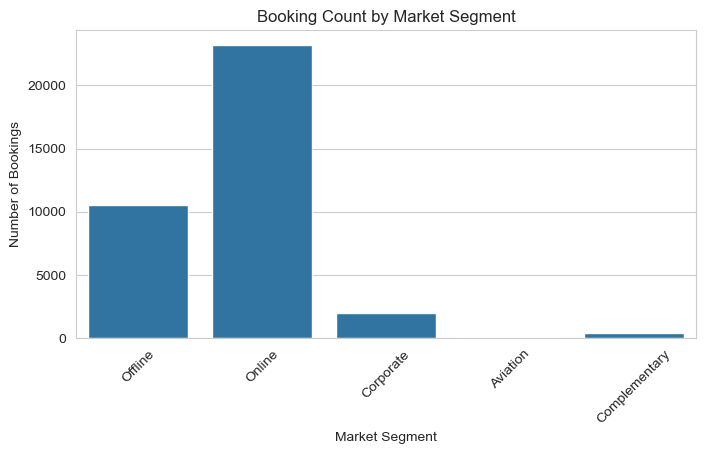

In [26]:
# 1. Market Segment Distribution

plt.figure(figsize=(8,4))
sns.countplot(x='market segment type', data=data)
plt.title('Booking Count by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

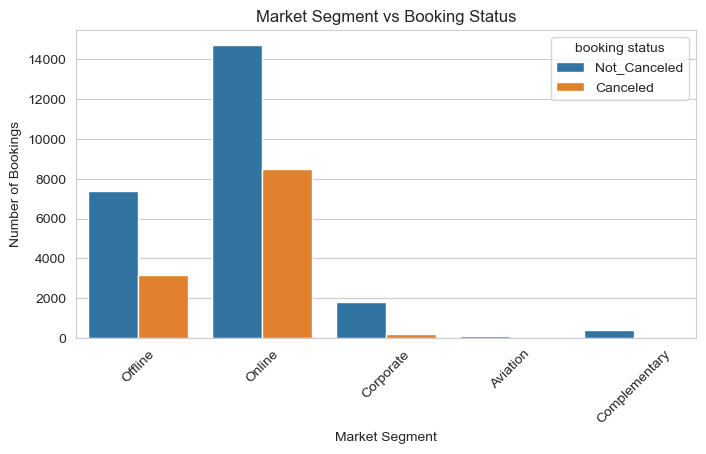

In [27]:
# 2. Market Segment vs Booking Status

plt.figure(figsize=(8,4))
sns.countplot(
    x='market segment type',
    hue='booking status',
    data=data
)

plt.title('Market Segment vs Booking Status')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

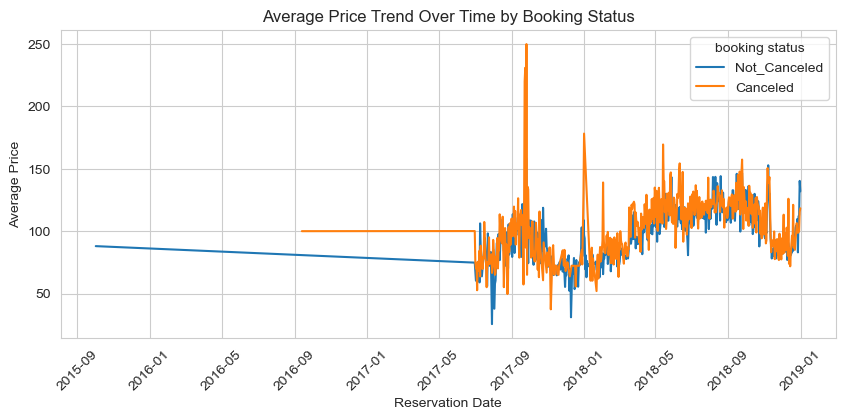

In [29]:
# 4. Average Price Trend Over Time by Booking Status

price_trend = data.groupby(['date of reservation', 'booking status'])['average price'].mean().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(
    x='date of reservation',
    y='average price',
    hue='booking status',
    data=price_trend
)

plt.title('Average Price Trend Over Time by Booking Status')
plt.xlabel('Reservation Date')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

####  Duplicate Check

In [22]:
# Check exact duplicate rows before dropping Booking_ID.
# Booking_ID is unique, so exact duplicates with Booking_ID included are unlikely.

duplicate_before_dropping_id = data.duplicated().sum()
print("Exact duplicate rows before dropping Booking_ID:", duplicate_before_dropping_id)

Exact duplicate rows before dropping Booking_ID: 0


In [23]:
# Check duplicated booking patterns after excluding Booking_ID.
# IMPORTANT:
# We do not remove these rows automatically because different customers can make
# bookings with the same details. Removing them after dropping Booking_ID could
# delete valid observations and reduce the real booking frequency patterns.

duplicate_after_excluding_id = data.drop(columns=["Booking_ID"]).duplicated().sum()
print("Duplicate-looking rows after excluding Booking_ID:", duplicate_after_excluding_id)

# No duplicate removal is performed here.
print("Shape retained for modeling:", data.shape)

Duplicate-looking rows after excluding Booking_ID: 10274
Shape retained for modeling: (36248, 22)


#### Create the Target Variable

In [24]:
# Create the target variable exactly as required:
# Canceled = 1
# Not_Canceled = 0

data["is_canceled"] = data["booking status"].map({
    "Canceled": 1,
    "Not_Canceled": 0
})

# Confirm that the target was created correctly
print(data[["booking status", "is_canceled"]].drop_duplicates())
print(data["is_canceled"].value_counts())

  booking status  is_canceled
0   Not_Canceled            0
2       Canceled            1
is_canceled
0    24366
1    11882
Name: count, dtype: int64


#### Prepare Features and Target

In [25]:
# Drop columns that should not be used as model inputs.
# Booking_ID is only an identifier.
# booking status is the original text target.
# date of reservation is removed because useful date parts were already extracted.

X = data.drop(columns=[
    "Booking_ID",
    "booking status",
    "is_canceled",
    "date of reservation"
])

y = data["is_canceled"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature shape: (36248, 19)
Target shape: (36248,)


,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,total_guests,total_nights,booking_month,booking_day,booking_year
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2,7,10,2,2015
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,1,4,11,6,2018
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,3,4,2,28,2018
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,1,2,5,20,2017
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,1,3,4,11,2018


#### Split the Data Before Scaling and SMOTE

In [31]:
# Split the data before scaling and SMOTE to prevent data leakage.
# stratify=y keeps the target class proportion similar in train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("y_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (28998, 19)
X_test shape: (7250, 19)
y_train distribution:
is_canceled
0    67.221877
1    32.778123
Name: proportion, dtype: float64
y_test distribution:
is_canceled
0    67.213793
1    32.786207
Name: proportion, dtype: float64


#### Fit Preprocessing Only on the Training Set

In [32]:
# Separate numerical and categorical columns.
# Numerical columns will be scaled with RobustScaler.
# Categorical columns will be encoded with OneHotEncoder.

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'car parking space', 'lead time', 'repeated', 'P-C', 'P-not-C', 'average price', 'special requests', 'total_guests', 'total_nights']
Categorical columns: ['type of meal', 'room type', 'market segment type']


In [33]:
# Fit RobustScaler only on the training numerical columns.
# Then transform both train and test using the same fitted scaler.

scaler = RobustScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

print("Numerical scaling completed without using test-set information.")

Numerical scaling completed without using test-set information.


In [34]:
# Fit OneHotEncoder only on the training categorical columns.
# handle_unknown='ignore' allows the model to handle new categories in test or future data.

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat_encoded = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_cat_encoded = pd.DataFrame(
    encoder.transform(X_test[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

print("Categorical encoding completed without using test-set information.")

Categorical encoding completed without using test-set information.


In [35]:
# Combine scaled numerical features and encoded categorical features.

X_train_processed = pd.concat(
    [X_train_num_scaled, X_train_cat_encoded],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num_scaled, X_test_cat_encoded],
    axis=1
)

# Store feature names for feature importance and future predictions.
feature_names = X_train_processed.columns.tolist()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
X_train_processed.head()

Processed training shape: (28998, 29)
Processed testing shape: (7250, 29)


,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,room type_Room_Type 7,market segment type_Aviation,market segment type_Complementary,market segment type_Corporate,market segment type_Offline,market segment type_Online
13113,0.0,0.0,-0.5,0.5,1.0,1.339450,0.0,0.0,0.0,0.147355,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20777,1.0,0.0,-0.5,-0.5,0.0,0.137615,0.0,0.0,0.0,1.507557,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6700,-1.0,0.0,0.5,0.5,0.0,-0.192661,0.0,0.0,0.0,0.265743,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
34469,0.0,0.0,1.0,1.5,0.0,0.899083,0.0,0.0,0.0,-0.107053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7952,-1.0,0.0,-0.5,0.0,0.0,-0.431193,0.0,0.0,0.0,0.316121,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#### Apply SMOTE Only on the Training Set

In [36]:
# Check class distribution before SMOTE.
# The test set is not touched because it must represent real unseen data.

print("Training target distribution before SMOTE:")
print(y_train.value_counts())

Training target distribution before SMOTE:
is_canceled
0    19493
1     9505
Name: count, dtype: int64


In [37]:
# Apply SMOTE only to the processed training data.
# This balances the training classes without leaking information into the test set.

smote = SMOTE(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Training target distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Training target distribution after SMOTE:
is_canceled
1    19493
0    19493
Name: count, dtype: int64


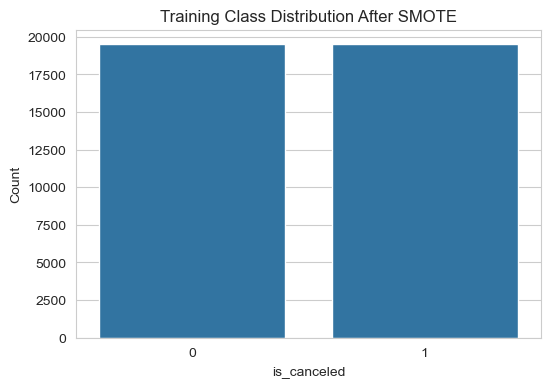

In [38]:
# Visualize balanced training class distribution after SMOTE.

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled)
plt.title("Training Class Distribution After SMOTE")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

#### Build and Compare Machine Learning Models

In [39]:
# Initialize the required models.
# Logistic Regression uses max_iter to help the algorithm converge.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

In [40]:
# Train each model on the SMOTE-balanced training set.
# Evaluate each model on the original untouched test set.

results = []
fitted_models = {}

for model_name, model in models.items():
    # Train model
    model.fit(X_train_resampled, y_train_resampled)

    # Save fitted model for later use
    fitted_models[model_name] = model

    # Predict class labels
    y_pred = model.predict(X_test_processed)

    # Predict probabilities for ROC-AUC
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

    # Store model metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.883724,0.818786,0.828776,0.823751,0.941168
3,Gradient Boosting,0.824414,0.705510,0.797223,0.748568,0.907716
0,Logistic Regression,0.779172,0.634816,0.768616,0.695338,0.861053
1,Decision Tree,0.857931,0.765890,0.816155,0.790224,0.849128


In [41]:
# Display model comparison in a clean table.
# Higher values are better for all metrics.

results_df.style.background_gradient(cmap="Blues")

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.883724,0.818786,0.828776,0.823751,0.941168
3,Gradient Boosting,0.824414,0.705510,0.797223,0.748568,0.907716
0,Logistic Regression,0.779172,0.634816,0.768616,0.695338,0.861053
1,Decision Tree,0.857931,0.765890,0.816155,0.790224,0.849128



Logistic Regression Confusion Matrix


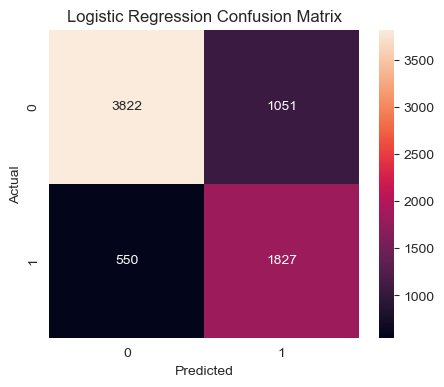


Decision Tree Confusion Matrix


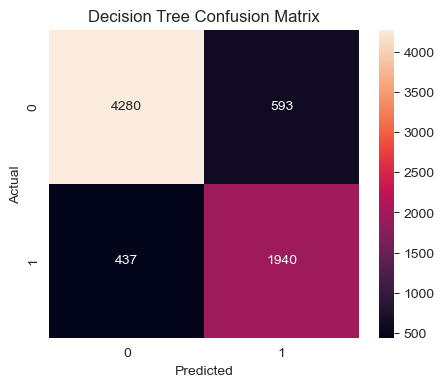


Random Forest Confusion Matrix


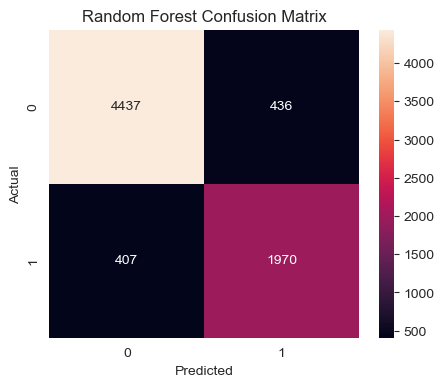


Gradient Boosting Confusion Matrix


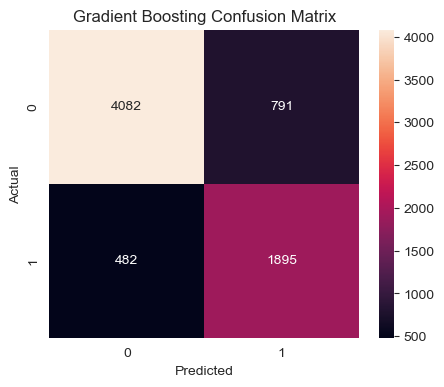

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through all trained models
for model_name, model in fitted_models.items():

    # Predictions
    y_pred = model.predict(X_test_processed)

    # Confusion Matrix
    matrix = confusion_matrix(y_test, y_pred)

    # Print title
    print(f"\n{model_name} Confusion Matrix")

    # Plot
    plt.figure(figsize=(5,4))

    sns.heatmap(
        matrix,
        annot=True,
        fmt='g'
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Save image
    safe_name = model_name.replace(" ", "_")
    plt.savefig(f"{safe_name}_confusion_matrix.png",
                bbox_inches='tight')

    plt.show()


Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4873
           1       0.63      0.77      0.70      2377

    accuracy                           0.78      7250
   macro avg       0.75      0.78      0.76      7250
weighted avg       0.80      0.78      0.78      7250



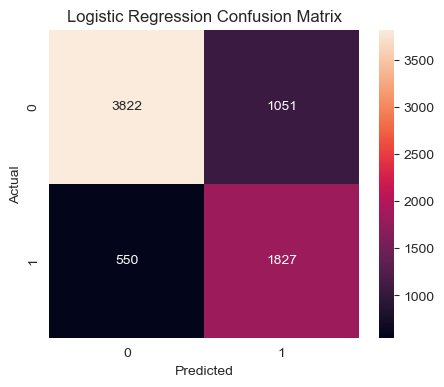


Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4873
           1       0.77      0.82      0.79      2377

    accuracy                           0.86      7250
   macro avg       0.84      0.85      0.84      7250
weighted avg       0.86      0.86      0.86      7250



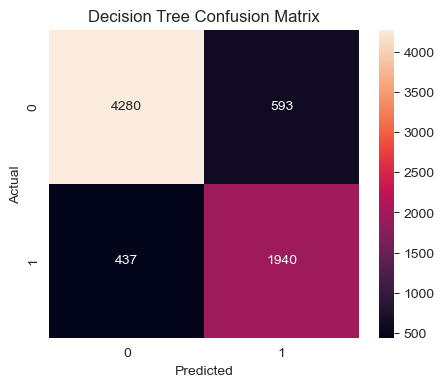


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      4873
           1       0.82      0.83      0.82      2377

    accuracy                           0.88      7250
   macro avg       0.87      0.87      0.87      7250
weighted avg       0.88      0.88      0.88      7250



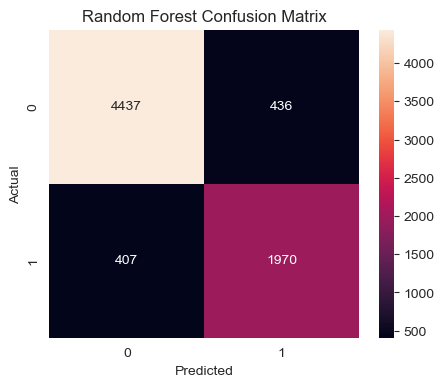


Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      4873
           1       0.71      0.80      0.75      2377

    accuracy                           0.82      7250
   macro avg       0.80      0.82      0.81      7250
weighted avg       0.83      0.82      0.83      7250



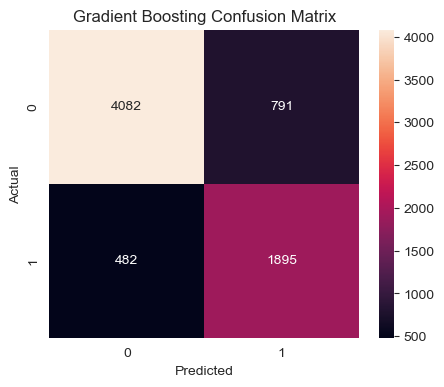

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through all trained models
for model_name, model in fitted_models.items():

    # Make predictions
    y_pred = model.predict(X_test_processed)

    # Classification Report
    print("\n" + "="*60)
    print(f"{model_name} Classification Report")
    print("="*60)

    report = classification_report(y_test, y_pred)
    print(report)

    # Confusion Matrix
    matrix = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(5,4))

    sns.heatmap(
        matrix,
        annot=True,
        fmt='g'
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Save confusion matrix image
    safe_name = model_name.replace(" ", "_")

    plt.savefig(
        f"{safe_name}_confusion_matrix.png",
        bbox_inches='tight'
    )

    plt.show()

#### Select the Final Model

In [44]:
# Select the best model based on ROC-AUC.
# ROC-AUC is useful because it evaluates the model's ability to rank cancellation risk.

best_model_name = results_df.iloc[0]["Model"]
final_model = fitted_models[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

# Use Random Forest as final model if it performs best.
if best_model_name == "Random Forest":
    print("Random Forest performs best and will be used as the final model.")
else:
    print(f"{best_model_name} performs best based on ROC-AUC.")
    print("If business preference requires Random Forest, compare its recall and ROC-AUC carefully before deployment.")

Best model based on ROC-AUC: Random Forest
Random Forest performs best and will be used as the final model.


In [45]:
# Detailed classification report for the final model

final_predictions = final_model.predict(X_test_processed)
final_probabilities = final_model.predict_proba(X_test_processed)[:, 1]

print("Final Model:", best_model_name)
print(classification_report(y_test, final_predictions, target_names=["Not_Canceled", "Canceled"]))

Final Model: Random Forest
              precision    recall  f1-score   support

Not_Canceled       0.92      0.91      0.91      4873
    Canceled       0.82      0.83      0.82      2377

    accuracy                           0.88      7250
   macro avg       0.87      0.87      0.87      7250
weighted avg       0.88      0.88      0.88      7250



#### Confusion Matrix

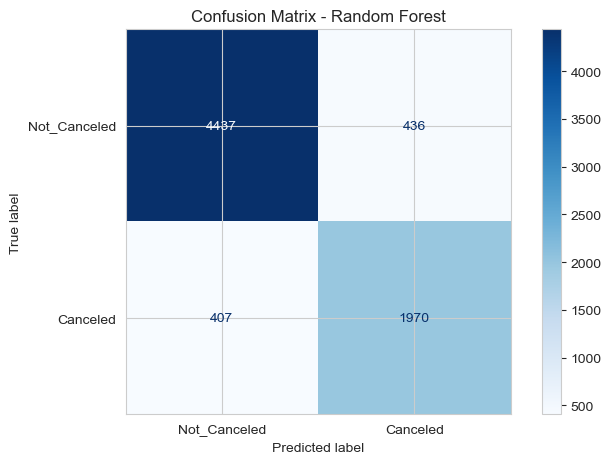

In [46]:
# Confusion matrix shows correct and incorrect predictions.
# This is especially important because false negatives mean actual cancellations were missed.

cm = confusion_matrix(y_test, final_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not_Canceled", "Canceled"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

#### ROC Curve

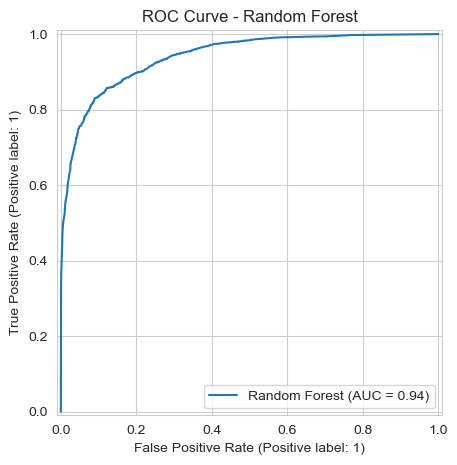

In [47]:
# ROC curve shows the trade-off between true positive rate and false positive rate.
# A larger area under the curve means better ranking performance.

RocCurveDisplay.from_predictions(
    y_test,
    final_probabilities,
    name=best_model_name
)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

#### Feature Importance

In [48]:
# Tree-based models provide feature importance directly.
# If Logistic Regression is selected, coefficient size is used instead.

if hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
else:
    importance_values = np.abs(final_model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
5,lead time,0.391741
9,average price,0.215009
10,special requests,0.120796
12,total_nights,0.047735
3,number of week nights,0.042831
2,number of weekend nights,0.034167
28,market segment type_Online,0.030611
27,market segment type_Offline,0.018466
11,total_guests,0.016198
0,number of adults,0.013285


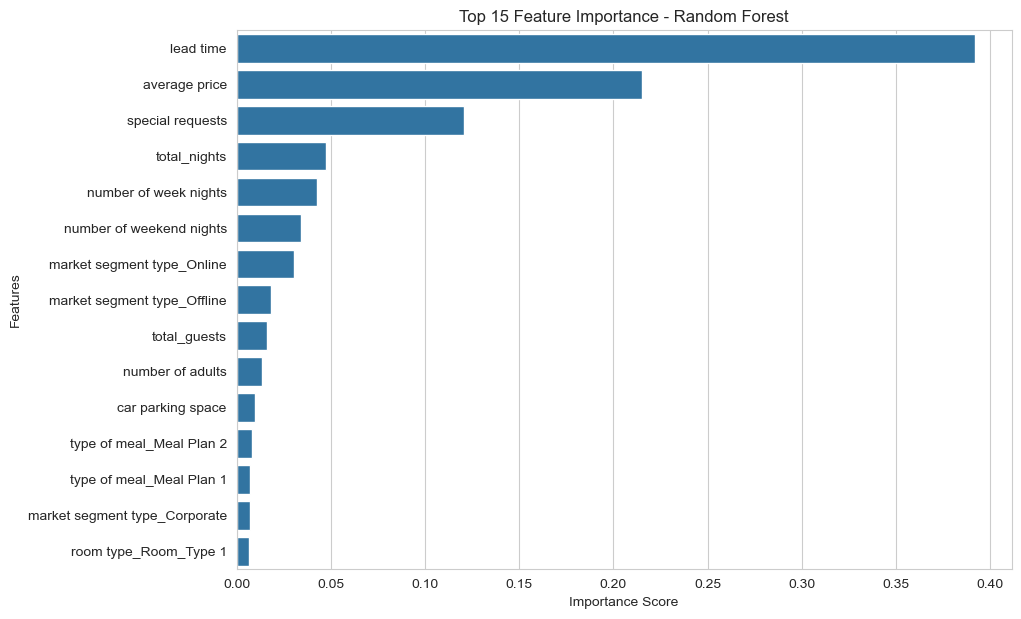

In [49]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Tree-based models provide feature importance directly.
# If Logistic Regression is selected, coefficient size is used instead.

if hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
else:
    importance_values = np.abs(final_model.coef_[0])

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
top_features = feature_importance.head(15)

# Plot feature importance
plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Save image
plt.savefig(
    "Random_Forest_Feature_Importance.png",
    bbox_inches='tight'
)

plt.show()

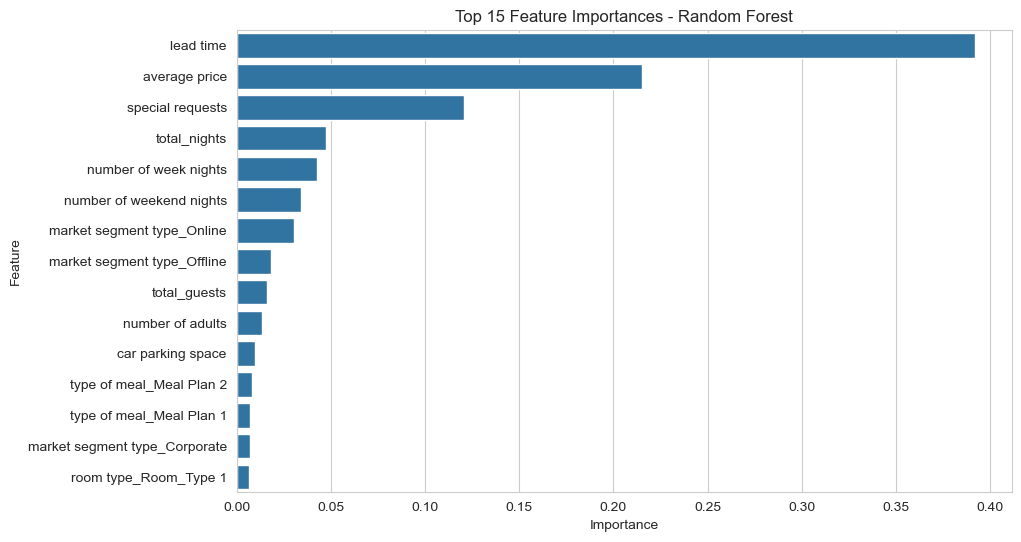

In [50]:
# Plot top 15 most important features.

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title(f"Top 15 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

#### Business Insights

In [51]:
# Cancellation rate by market segment
# This supports business recommendations for channel-specific cancellation control.

segment_cancellation = (
    data.groupby("market segment type")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

segment_cancellation["cancellation_rate_%"] = segment_cancellation["is_canceled"] * 100
segment_cancellation

,market segment type,is_canceled,cancellation_rate_%
0,Online,0.365157,36.515667
1,Offline,0.299686,29.968634
2,Aviation,0.296000,29.600000
3,Corporate,0.109398,10.939831
4,Complementary,0.000000,0.000000


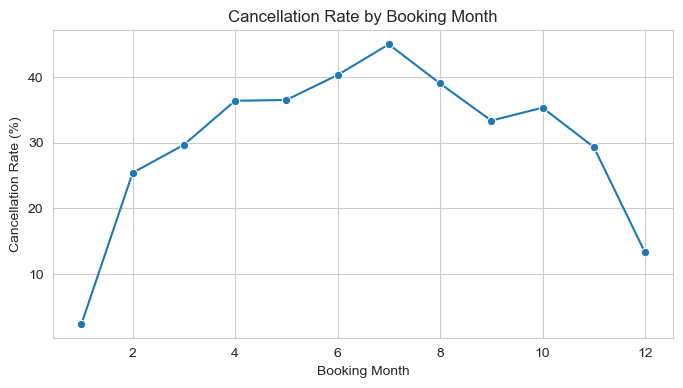

,booking_month,is_canceled,cancellation_rate_%
0,1,0.023669,2.366864
1,2,0.254197,25.419664
2,3,0.296862,29.686175
3,4,0.363902,36.390208
4,5,0.365140,36.514044
5,6,0.403060,40.305963
6,7,0.449846,44.984594
7,8,0.390244,39.024390
8,9,0.333695,33.369471
9,10,0.353383,35.338346


In [52]:
# Cancellation rate by booking month
# This helps identify seasonal cancellation risk.

monthly_cancellation = (
    data.groupby("booking_month")["is_canceled"]
    .mean()
    .reset_index()
)

monthly_cancellation["cancellation_rate_%"] = monthly_cancellation["is_canceled"] * 100

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=monthly_cancellation,
    x="booking_month",
    y="cancellation_rate_%",
    marker="o"
)
plt.title("Cancellation Rate by Booking Month")
plt.xlabel("Booking Month")
plt.ylabel("Cancellation Rate (%)")
plt.show()

monthly_cancellation

In [53]:
# Compare average lead time and price by cancellation status.
# This summarizes two important business drivers.

business_summary = data.groupby("booking status").agg({
    "lead time": "mean",
    "average price": "mean",
    "special requests": "mean",
    "total_nights": "mean",
    "total_guests": "mean"
}).round(2)

business_summary

,lead time,average price,special requests,total_nights,total_guests
booking status,,,,,
Canceled,139.27,110.60,0.33,3.28,2.03
Not_Canceled,58.96,99.94,0.76,2.89,1.91


####  Conclusion and Recommendations

### Conclusion

- This project predicts whether a hotel booking will be canceled using customer, booking, pricing, stay duration, and - channel information. The corrected workflow prevents data leakage by splitting the data before preprocessing, fitting RobustScaler only on the training set, and applying SMOTE only to the training set.

- Business recommendations

- Monitor bookings with long lead times because customers who book far in advance may have a higher chance of canceling.
- Pay close attention to online bookings because online channels often show stronger cancellation behavior.

- Use cancellation-risk scores to send reminders, request confirmation, or offer non-refundable discounts to high-risk customers.
- During peak months, apply stricter cancellation policies or targeted retention strategies.
- Use important model features such as lead time, average price, special requests, and market segment to guide hotel revenue management decisions.

#### Save Final Model and Scaler

In [54]:
# Save the final model and preprocessing objects using joblib.
# The scaler is saved separately as required.
# The encoder and feature names are also saved so future data can be transformed consistently.

joblib.dump(final_model, "hotel_booking_final_model.pkl")
joblib.dump(scaler, "hotel_booking_robust_scaler.pkl")
joblib.dump(encoder, "hotel_booking_onehot_encoder.pkl")
joblib.dump(feature_names, "hotel_booking_feature_names.pkl")

print("Final model saved as: hotel_booking_final_model.pkl")
print("Scaler saved as: hotel_booking_robust_scaler.pkl")
print("Encoder saved as: hotel_booking_onehot_encoder.pkl")
print("Feature names saved as: hotel_booking_feature_names.pkl")

Final model saved as: hotel_booking_final_model.pkl
Scaler saved as: hotel_booking_robust_scaler.pkl
Encoder saved as: hotel_booking_onehot_encoder.pkl
Feature names saved as: hotel_booking_feature_names.pkl
